## Temporal Plots
Temporal Mapper constructs a graph which does not have an inherent visualization. Moreover, if your data has $d$ semantic dimensions, then the graph 'naturally' lives in $d+1$ dimensions when including time.

A temporal plot of a `TemporalMapper` is a 2d plot where the $x$-axis of a vertex is the median time of its corresponding cluster. For the $y$-axis, you can either pass a 1d reduction of your data or you can use an optimization algorithm to minimize the number of edge crossings. 

Let's demonstrate a Temporal Plot by fitting a `TemporalMapper` to a small dataset of 10,000 arXiv machine learning papers. The paper's titles and abstracts were concatenated and embedded using the sentence transformer [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2), and then reduced to 2D with UMAP.

In [1]:
import temporalmapper as tm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, io
from fast_hdbscan import HDBSCAN

In [2]:
response = requests.get(
    'https://github.com/TutteInstitute/temporal-mapper/raw/refs/heads/docs/docs/data/ai_arxiv_coordinates.npy'
)
map_data = np.load(io.BytesIO(response.content))

response = requests.get(
    'https://github.com/TutteInstitute/temporal-mapper/raw/refs/heads/docs/docs/data/ai_arxiv_data.feather'
)
df = pd.read_feather(io.BytesIO(response.content))

df.head()

,title,abstract,id,created,authors,arxiv,doi
0,automated rating of recorded classroom present...,effective presentation skills can help to succ...,1801.00453,2018-01-01,"[akzharkyn izbassarova, aidana irmanova, a. p....",cs.ai,10.1109/icacci.2017.8125872
1,accelerating deep learning with memcomputing,restricted boltzmann machines (rbms) and their...,1801.00512,2018-01-01,"[haik manukian, fabio l. traversa, massimilian...",cs.ai,
2,accelerating deep learning with memcomputing,restricted boltzmann machines (rbms) and their...,1801.00512,2018-01-01,"[haik manukian, fabio l. traversa, massimilian...",cs.lg,
3,accurate reconstruction of image stimuli from ...,"in neuroscience, all kinds of computation mode...",1801.00602,2018-01-02,"[kai qiao, chi zhang, linyuan wang, bin yan, j...",cs.ai,
4,deep learning: a critical appraisal,although deep learning has historical roots go...,1801.00631,2018-01-02,[gary marcus],cs.lg,


In [3]:
# Compute a time column T which is the number of days since Jan 01, 2018.
def date_to_T(date):
    d0 = pd.Timestamp('2018-01-01')
    delta = date-d0
    return delta.days

df["date"] = pd.to_datetime(df["created"])
df["T"] = df["date"].apply(
    lambda x: date_to_T(x)
)
time = df["T"].to_numpy().reshape(-1,1)

In [9]:
clusterer = HDBSCAN(
    cluster_selection_method='eom',
    min_cluster_size=15,
)
mapper = tm.TemporalMapper(
    clusterer = clusterer,
    slice_method = 'data',
    n_slices = 8,
    kernel=tm.kernels.square
)

X = np.concatenate([map_data, time],axis=1)
mapper.fit(X)

,time,"array([ 0., ...hape=(10000,))"
,data,"array([[ 4.82...pe=(10000, 2))"
,clusterer,HDBSCAN(min_cluster_size=15)
,n_slices,8
,n_neighbors,5
,overlap,0.5
,inclusion_threshold,0.01
,slice_method,'data'
,density_based,True
,kernel,<function squ...x70f2f4e7a5c0>
,kernel_params,None


### Static Temporal Plots

Now that we've fit a `TemporalMapper`, we can call its `temporal_plot` method which returns a matplotlib axis. By default, each vertex is labeled with `t:c` where `t` is the index of the temporal slice of the vertex, and `c` is the cluster number within that slice. 

<Axes: >

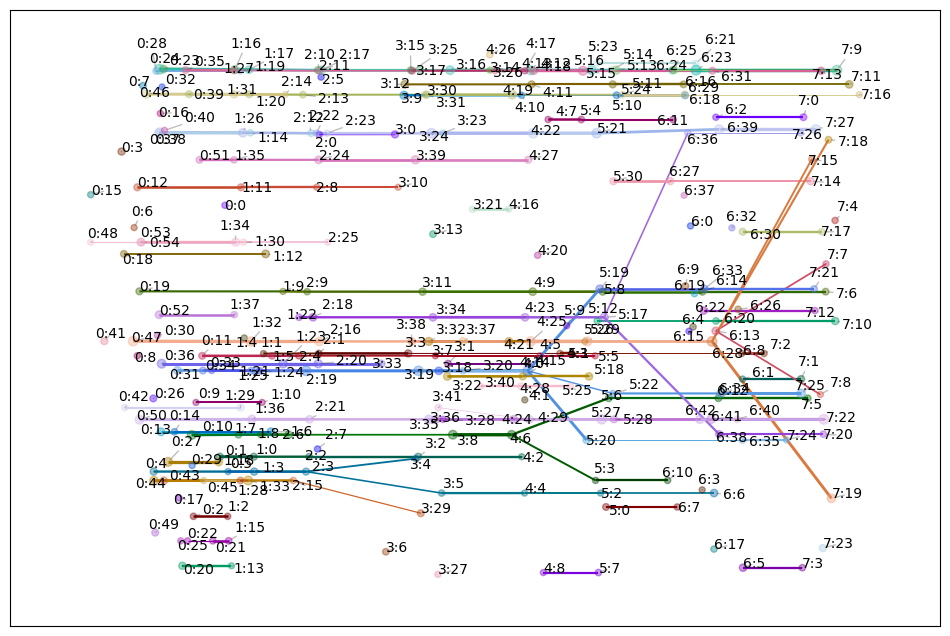

In [12]:
mapper.temporal_plot()

There are a couple layout options that can be chosen. 
* Barycenter - Non deterministic optimization, quick and decent results.
* Semantic - Accepts a `y_values` parameter for the points of the dataset and plots each vertex on its median value. If no `y_value` is passed, it uses the angle for 2d data and PCA to 1d for 3d+.
* Ordered - Custom made layout function for typical temporal mapper graphs. Best results but can be slow on large graphs (like 100s of vertices).

By default, ordered is used when the graph has under 100 vertices, and barycenter is used otherwise.

<Axes: >

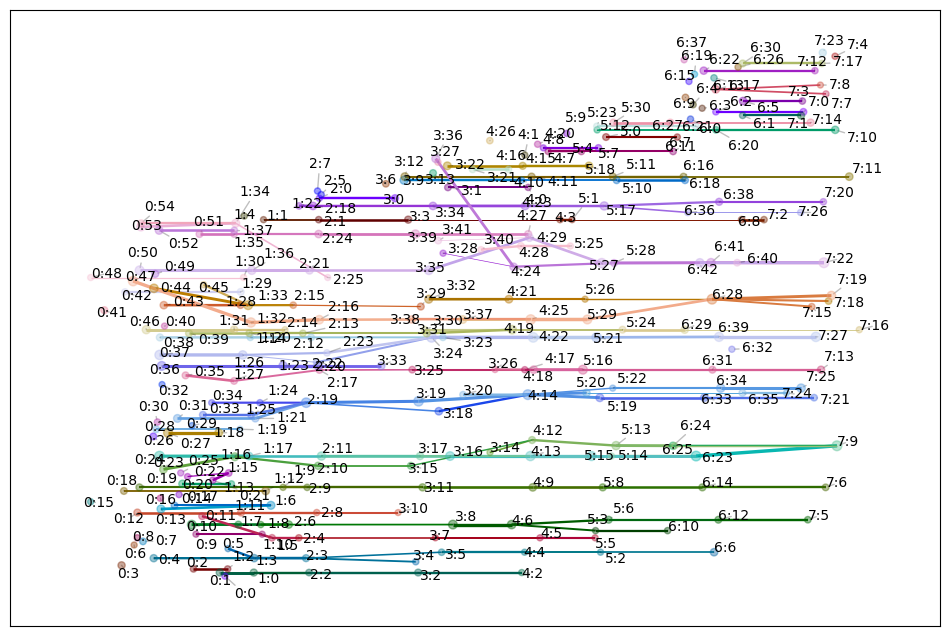

In [11]:
mapper.temporal_plot(layout='ordered')


The optional `ax` argument allows you to pass a pre-made matplotlib axis, allowing you to add additional information to the plot as you wish.

We can also use the `generate_keyword_labels` function from `temporalmapper.plotting` to generate some keywords to use as labels for the vertices. This function takes a bag-of-words for each datapoint as input. To keep it simple, we'll split the abstract and title on spaces, this won't give great labels, but its better than nothing.

Generating keywords: 100%|██████████| 8/8 [00:00<00:00,  8.80it/s]


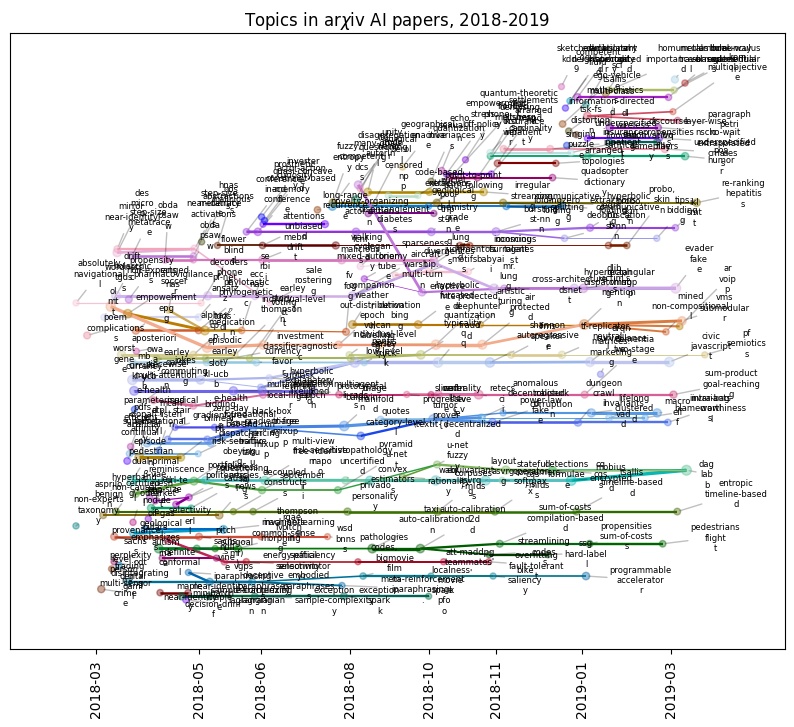

In [14]:
from sklearn.decomposition import PCA
from datetime import datetime, timedelta

## Generate informative keywords
content = (df['title']+df['abstract']).to_numpy()
word_bags = []
for c in content:
    word_bags.append(c.split(" "))

cluster_labels = tm.plotting.generate_keyword_labels(word_bags, mapper, sep='\n')

## Create Temporal Plot
fig, ax = plt.subplots(1,1)
mapper.temporal_plot(
    ax=ax,
    cluster_labels=cluster_labels,
    cluster_label_kwargs={"fontsize":6},
    layout='ordered',
)
label_times = mapper.midpoints
label_dates = [
    (pd.Timestamp('2018-01-01')+timedelta(days=int(x))).strftime('%Y-%m')
     for x in label_times
]
ax.set_xticks(label_times,labels=label_dates)
ax.tick_params(axis='x', labelrotation=90)
fig.set_figwidth(10)
fig.set_figheight(8)
ax.set_title("Topics in ar$\chi$iv AI papers, 2018-2019")
ax.tick_params(bottom=True, labelbottom=True)
plt.show()

As you can see, for any appreciably complex dataset, the full Mapper graph will be hard to interpret. Instead, we can plot subgraphs. To plot the subgraph spanned by a list of vertices, `s`, you can pass the list to `temporal_plot` with `vertices=s`.

For example, `TemporalMapper.vertex_subgraph(node)` will return the subgraph spanned by all the ancestors and descendants of `node`.

In [17]:
mapper.vertex_subgraph('4:12')

array(['0:23', '0:24', '1:16', '2:10', '3:14', '3:15', '4:12', '5:13',
       '6:24', '6:25', '7:9'], dtype='<U4')

We can pass this to the plotting function to see just this subgraph.

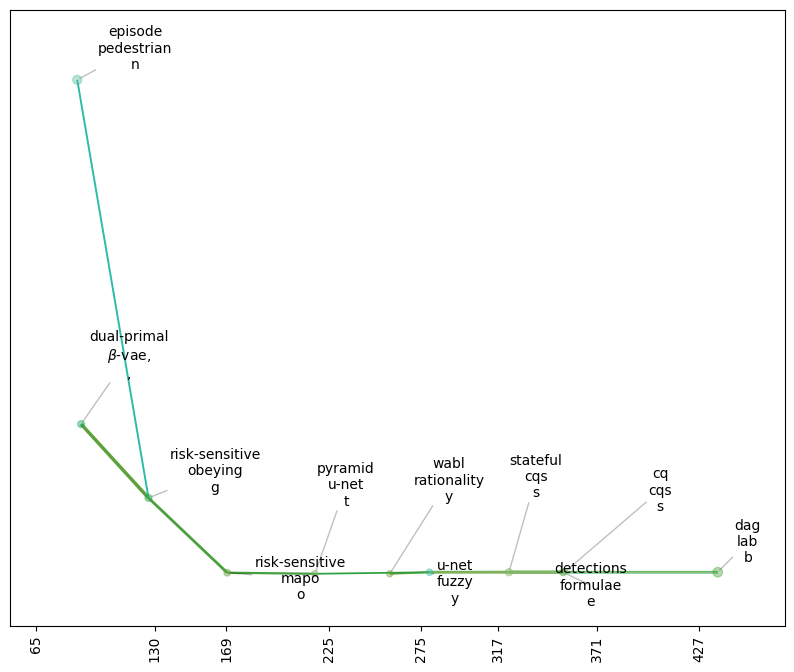

In [19]:
from sklearn.decomposition import PCA
from datetime import datetime, timedelta

y_axis =  PCA(n_components=1).fit_transform(mapper.data)

fig, ax = plt.subplots(1,1)


mapper.temporal_plot(
    ax=ax,
    vertices=mapper.vertex_subgraph('4:12'),
    cluster_labels=cluster_labels,
    cluster_label_kwargs={"fontsize":10},
)

ax.tick_params(bottom=True, labelbottom=True)
fig.set_figwidth(10)
fig.set_figheight(8)
plt.show()

The `temporal_plot` uses `networkx`'s plotting functions, `draw_networkx_nodes` and `draw_networkx_edges`. If you want to further customize the look of the plot, you can pass dictionaries `node_kwargs` and `edge_kwargs` that will be passed along to these functions.

Other notable customizations are:

```
edge_scaling : float, default 1
    Scaling factor applied to edge weights or widths.
node_scaling : float, default 1
    Scaling factor applied to node sizes.
node_size_bounds :  tuple[float], default (5,25)
    Size bounds to clip the node sizes to.
edge_weight_bounds : tuple[float], default (0.1,1)
    Size bounds to clip the edge thicknesses to.
node_size_scale : {'linear', 'log', 'sigmoid'}, default 'sigmoid'
    Scaling mode used for node sizes.
```

### Interactive Temporal Plot

Even better than plotting subgraphs, we can generate an interactive temporal plot using Plotly.


In [21]:
import plotly.io as pio
pio.renderers.default = 'sphinx_gallery'

mapper.interactive_temporal_plot()

The interactive plot is not as customizable as the static plot, but you can still make some customizations:

In [22]:
from plotly.graph_objects import Layout

mapper.interactive_temporal_plot(
    hover_text=cluster_labels,
    graph_layout=Layout(
        title=dict(text="Topics in arXiv AI papers, 2018-2019"),
        width=1000,
        height=600,
        showlegend=False,
    )
)